# Exploratory Data Analysis & Data Cleaning
## Amazon App Reviews Dataset

**Objective**: Understand the dataset, identify data quality issues, engineer features, and prepare clean model-ready datasets for:
1. Anomaly detection — fake review identification (Phase 2)
2. Sentiment analysis — binary classification (Phase 3)

**Pipeline output**: Two CSV files:
- `reviews_clean_all.csv` — all reviews including neutrals (for anomaly detection)
- `reviews_clean_full.csv` — neutrals removed, sentiment labeled (for sentiment analysis)

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

# Configuration
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
# plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RANDOM_SEED = 42
DATA_PATH   = "../Data/amazon_reviews.csv"
OUTPUT_DIR  = "../Data/"   # Data directory for output CSVs
IMG_DIR     = "../Images/"  # Directory for output images

STOP_WORDS = set(stopwords.words("english"))

print("Setup complete.")

Setup complete.


## 1. Load Data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes)
df.head()

Shape: (83985, 8)

Column dtypes:
reviewId                object
userName                object
content                 object
score                    int64
thumbsUpCount            int64
reviewCreatedVersion    object
at                      object
appVersion              object
dtype: object


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,961ce5e0-018f-4fcd-9e19-600ca2f248b9,Gary Perkins,"Need to add a ""Filter on number of reviews"" functionality. Why? There seems to be many 5 star products which have a low number (say 20) of reviews which could imply the reviews have been rigged. B...",5,0,32.2.0.100,2026-02-01 09:56:54,32.2.0.100
1,2483aae8-b456-4dc0-803a-ccd3e3e512d9,Ashley Johnson,No longer compatible with Samsung Galaxy tablet. Amazon trying to make life difficult for people. The only reason Amazon want to prohibit people from using the App on their tablets is because they...,1,0,30.22.2.100,2026-02-01 09:50:00,30.22.2.100
2,e5b73f0c-6678-4992-b465-68836f1adfe0,Daithi Heneghan,Great postage for free love Amazon ❤️,5,0,32.2.0.100,2026-02-01 09:25:58,32.2.0.100
3,9cacc4cc-9ec2-428e-b7ff-c174b34991ab,mufiz shaikh,good,5,0,32.2.0.100,2026-02-01 09:04:07,32.2.0.100
4,87716296-dd4c-4c8f-a83c-a638b38ef983,Bryan Santiago,good 👍,5,0,32.2.0.100,2026-02-01 08:50:25,32.2.0.100


## 2. Data Quality Summary

In [4]:
# Missing values
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(3)

# Duplicates
dup_full     = df.duplicated().sum()
dup_reviewId = df.duplicated(subset=["reviewId"]).sum()
dup_content  = df.duplicated(subset=["content"]).sum()

# Summary table
quality = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct,
    "n_unique": df.nunique(dropna=True),
    "dtype": df.dtypes.astype(str)
}).sort_values("missing_%", ascending=False)

print(f"Duplicate FULL rows:    {dup_full}")
print(f"Duplicate reviewId:     {dup_reviewId}")
print(f"Duplicate content text: {dup_content}")
print(f"Missing content rows:   {df['content'].isna().sum()}")
print()
quality

Duplicate FULL rows:    114
Duplicate reviewId:     1916
Duplicate content text: 3766
Missing content rows:   6



,missing_count,missing_%,n_unique,dtype
reviewCreatedVersion,9606,11.438,268,object
appVersion,9606,11.438,268,object
userName,6,0.007,69620,object
content,6,0.007,80218,object
reviewId,0,0.000,82069,object
score,0,0.000,5,int64
thumbsUpCount,0,0.000,602,int64
at,0,0.000,83814,object


In [5]:
# Check whether reviewCreatedVersion and appVersion are always identical
both_present = df.dropna(subset=["reviewCreatedVersion", "appVersion"])
mismatches   = both_present[both_present["reviewCreatedVersion"] != both_present["appVersion"]]
both_missing = df[["reviewCreatedVersion", "appVersion"]].isna().all(axis=1).sum()

print(f"Rows where both versions present: {len(both_present)}")
print(f"Mismatches between the two columns: {len(mismatches)}")
print(f"Rows where both are NaN: {both_missing}")
print()
if len(mismatches) == 0:
    print("FINDING: reviewCreatedVersion and appVersion are always identical.")
    print("ACTION:  We will keep 'appVersion' and drop 'reviewCreatedVersion'.")

Rows where both versions present: 74379
Mismatches between the two columns: 0
Rows where both are NaN: 9606

FINDING: reviewCreatedVersion and appVersion are always identical.
ACTION:  We will keep 'appVersion' and drop 'reviewCreatedVersion'.


## 3. Data Cleaning

Steps:
1. Parse datetime and extract time features
2. Remove duplicate `reviewId` (keep latest by timestamp)
3. Drop redundant `reviewCreatedVersion` column
4. Fill missing `appVersion` with "unknown"
5. Clean review text (lowercase, URL removal, whitespace normalization)
6. Drop empty/NaN content rows (with validation message)
7. Handle "A Google user" anonymous placeholder

In [6]:
# Parse datetime
df["at"] = pd.to_datetime(df["at"], errors="coerce")
bad_dates = df["at"].isna().sum()
print(f"Missing/invalid 'at' after parsing: {bad_dates}")

# Time features (useful for downstream anomaly detection patterns)
df["date"]        = df["at"].dt.date
df["year"]        = df["at"].dt.year
df["month"]       = df["at"].dt.month
df["day_of_week"] = df["at"].dt.dayofweek   # 0=Monday
df["hour"]        = df["at"].dt.hour

print(f"Date range: {df['at'].min()} to {df['at'].max()}")

Missing/invalid 'at' after parsing: 0
Date range: 2018-09-12 10:08:56 to 2026-02-01 09:56:54


In [7]:
# Remove duplicate reviewId (keep latest by timestamp)
before = df.shape[0]
df = df.sort_values("at").drop_duplicates(subset=["reviewId"], keep="last").reset_index(drop=True)
print(f"Removed {before - df.shape[0]} duplicate reviewId rows")
print(f"Shape after dedup: {df.shape}")

Removed 1916 duplicate reviewId rows
Shape after dedup: (82069, 13)


In [8]:
# Drop redundant reviewCreatedVersion (always identical to appVersion)
df = df.drop(columns=["reviewCreatedVersion"])

# Fill missing appVersion
df["appVersion"] = df["appVersion"].fillna("unknown").astype(str)

# Ensure numeric columns
df["score"]         = pd.to_numeric(df["score"], errors="coerce")
df["thumbsUpCount"] = pd.to_numeric(df["thumbsUpCount"], errors="coerce").fillna(0).astype(int)

print(f"Columns after cleanup: {df.columns.tolist()}")

Columns after cleanup: ['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'at', 'appVersion', 'date', 'year', 'month', 'day_of_week', 'hour']


In [9]:
# Enhanced text cleaning
URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+)", re.IGNORECASE)

def clean_text(s: str) -> str:
    """Clean review text: strip, remove URLs, normalize whitespace, lowercase."""
    if pd.isna(s) or str(s).strip() == "":
        return ""
    s = str(s).strip()
    s = URL_PATTERN.sub(" ", s)       # Remove URLs entirely
    s = re.sub(r"\s+", " ", s)        # Normalize whitespace
    s = s.lower()                      # Lowercase for NLP consistency
    return s.strip()

df["content"] = df["content"].astype(str)
df["content_clean"] = df["content"].apply(clean_text)

df[["content", "content_clean"]].head(3)

,content,content_clean
0,"It worked at first, but now I can't access the app whenever I tap on the icon. If you can fix it, I might download it again.","it worked at first, but now i can't access the app whenever i tap on the icon. if you can fix it, i might download it again."
1,I have the galaxy note 8 the app doesn't allow me to order. I have tried it on 4 other devices. I can't order unless I'm on my laptop. It's been close to a year that I have been able to just purch...,i have the galaxy note 8 the app doesn't allow me to order. i have tried it on 4 other devices. i can't order unless i'm on my laptop. it's been close to a year that i have been able to just purch...
2,Can no longer log in to Amazon apps. Neither main app nor Amazon Music allow me to sign in as do not recognise the email associated with my well established Amazon account. Renders both useless. W...,can no longer log in to amazon apps. neither main app nor amazon music allow me to sign in as do not recognise the email associated with my well established amazon account. renders both useless. w...


In [10]:
# Drop empty content with explicit validation message
before = df.shape[0]
df = df[df["content_clean"].str.strip().ne("")].reset_index(drop=True)
dropped = before - df.shape[0]

if dropped == 0:
    print(f"Validation: 0 rows dropped for empty content (all {df.shape[0]} reviews have text)")
else:
    print(f"Dropped {dropped} rows with empty content_clean")

print(f"Shape after text cleaning: {df.shape}")

Validation: 0 rows dropped for empty content (all 82069 reviews have text)
Shape after text cleaning: (82069, 13)


In [11]:
# Handle "A Google user" anonymous placeholder
df["userName"] = df["userName"].fillna("unknown").astype(str)
df["is_anonymous_user"] = (df["userName"] == "A Google user").astype(int)

anon_count = df["is_anonymous_user"].sum()
print(f"Anonymous ('A Google user') reviews: {anon_count} ({anon_count/len(df)*100:.1f}%)")

Anonymous ('A Google user') reviews: 7788 (9.5%)


## 4. Feature Engineering

### Text features:
- `char_len`, `word_count`, `avg_word_len` — text length
- `exclamation_count`, `question_count`, `digit_count` — punctuation/content signals
- `has_url` — URL presence flag (checked on original text)
- `caps_ratio` — uppercase letter ratio (computed on original text before lowercasing)
- `emoji_count` — proper Unicode emoji count
- `repeated_char_flag` — e.g. "sooooo", "goooood"
- `is_duplicate_text`, `dup_text_weight` — duplicate content detection
- `reviews_by_userName` — user activity count (fixed for anonymous users)

### New features:
- `is_very_short` — review is 3 words or fewer
- `unique_word_ratio` — lexical diversity
- `stopword_ratio` — proportion of stopwords
- `punctuation_ratio` — punctuation density
- `score_extremity` — distance from neutral (`|score - 3|`)
- `vader_compound` — VADER sentiment polarity score

In [12]:
# --- Text length features ---
df["char_len"]     = df["content_clean"].str.len()
df["word_count"]   = df["content_clean"].str.split().apply(len)
df["avg_word_len"] = (df["char_len"] / df["word_count"].replace(0, np.nan)).fillna(0)

# --- Punctuation / content count features (on ORIGINAL text to preserve casing) ---
df["exclamation_count"] = df["content"].str.count(r"!")
df["question_count"]    = df["content"].str.count(r"\?")
df["digit_count"]       = df["content"].str.count(r"\d")
df["has_url"]           = df["content"].str.contains(r"(https?://|www\.)", case=False, regex=True).astype(int)

# --- Caps ratio (on ORIGINAL text, before lowercasing) ---
def calc_caps_ratio(s: str) -> float:
    letters = [c for c in str(s) if c.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

df["caps_ratio"] = df["content"].apply(calc_caps_ratio)

print(f"Basic features created. Shape: {df.shape}")

C:\Users\91727\AppData\Local\Temp\ipykernel_2504\2365635691.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_url"]           = df["content"].str.contains(r"(https?://|www\.)", case=False, regex=True).astype(int)


Basic features created. Shape: (82069, 22)


In [14]:
# --- Proper emoji count (fixed: uses Unicode emoji ranges, not all non-ASCII) ---
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"   # emoticons
    "\U0001F300-\U0001F5FF"   # symbols & pictographs
    "\U0001F680-\U0001F6FF"   # transport & map
    "\U0001F1E0-\U0001F1FF"   # flags
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "\U0001F900-\U0001F9FF"   # supplemental symbols
    "\U0001FA00-\U0001FA6F"   # chess symbols
    "\U0001FA70-\U0001FAFF"   # symbols extended-A
    "]+", flags=re.UNICODE
)

def count_emojis(s: str) -> int:
    return len(EMOJI_PATTERN.findall(str(s)))

df["emoji_count"] = df["content"].apply(count_emojis)   # Use original text

# --- Repeated character flag ---
df["repeated_char_flag"] = df["content_clean"].apply(
    lambda s: 1 if re.search(r"(.)\1{3,}", s) else 0
)

print(f"emoji_count stats: mean={df['emoji_count'].mean():.2f}, "
      f"max={df['emoji_count'].max()}, non-zero={df['emoji_count'].gt(0).sum()}")
print(f"repeated_char_flag: {df['repeated_char_flag'].sum()} reviews flagged")

emoji_count stats: mean=0.08, max=58, non-zero=5155
repeated_char_flag: 3236 reviews flagged


In [15]:
# --- Weighted duplicate text flag ---
# Short generic duplicates ("good", "great") are less suspicious than
# long duplicates which suggest copy-paste spam.
df["is_duplicate_text"] = df.duplicated(subset=["content_clean"], keep=False).astype(int)
df["dup_text_weight"]   = np.where(
    df["is_duplicate_text"] == 1,
    np.clip(df["char_len"] / 50.0, 0.0, 1.0),
    0.0
)

dup_count = df["is_duplicate_text"].sum()
print(f"Duplicate text reviews: {dup_count} ({dup_count/len(df)*100:.1f}%)")
print(f"Dup weight stats (among duplicates):")
print(df.loc[df["is_duplicate_text"]==1, "dup_text_weight"].describe().round(3))
print()

# --- User activity (fixed for anonymous users) ---
user_counts = df["userName"].value_counts()
df["reviews_by_userName"] = df["userName"].map(user_counts).fillna(1).astype(int)

# Override for anonymous users — each is an independent unknown user
df.loc[df["is_anonymous_user"] == 1, "reviews_by_userName"] = 1

print(f"reviews_by_userName (non-anonymous) top 5:")
print(df.loc[df["is_anonymous_user"]==0, "reviews_by_userName"].value_counts().head())

Duplicate text reviews: 4586 (5.6%)
Dup weight stats (among duplicates):
count    4586.000
mean        0.181
std         0.114
min         0.020
25%         0.100
50%         0.160
75%         0.240
max         1.000
Name: dup_text_weight, dtype: float64

reviews_by_userName (non-anonymous) top 5:
1    67149
2     3334
3     1068
4      520
5      345
Name: reviews_by_userName, dtype: int64


In [16]:
# --- is_very_short: 3 words or fewer ---
df["is_very_short"] = (df["word_count"] <= 3).astype(int)
print(f"Very short reviews (<=3 words): {df['is_very_short'].sum()} "
      f"({df['is_very_short'].mean()*100:.1f}%)")

# --- unique_word_ratio: lexical diversity ---
def unique_word_ratio(text: str) -> float:
    words = str(text).split()
    if len(words) == 0:
        return 0.0
    return len(set(words)) / len(words)

df["unique_word_ratio"] = df["content_clean"].apply(unique_word_ratio)

# --- stopword_ratio ---
def stopword_ratio(text: str) -> float:
    words = str(text).split()
    if len(words) == 0:
        return 0.0
    sw_count = sum(1 for w in words if w in STOP_WORDS)
    return sw_count / len(words)

df["stopword_ratio"] = df["content_clean"].apply(stopword_ratio)

# --- punctuation_ratio ---
def punctuation_ratio(text: str) -> float:
    if len(str(text)) == 0:
        return 0.0
    punct_count = sum(1 for c in str(text) if c in '!?.,:;-()[]{}\"\'/\\@#$%^&*')
    return punct_count / len(str(text))

df["punctuation_ratio"] = df["content"].apply(punctuation_ratio)

# --- score_extremity: |score - 3| ---
df["score_extremity"] = (df["score"] - 3).abs()

print(f"\nNew feature summary:")
for col in ["is_very_short", "unique_word_ratio", "stopword_ratio",
            "punctuation_ratio", "score_extremity"]:
    print(f"  {col}: mean={df[col].mean():.3f}, std={df[col].std():.3f}")

Very short reviews (<=3 words): 7473 (9.1%)

New feature summary:
  is_very_short: mean=0.091, std=0.288
  unique_word_ratio: mean=0.891, std=0.098
  stopword_ratio: mean=0.404, std=0.155
  punctuation_ratio: mean=0.028, std=0.028
  score_extremity: mean=1.666, std=0.621


In [17]:
# --- VADER compound sentiment score ---
sid = SentimentIntensityAnalyzer()

# Apply to original content (VADER is case-sensitive)
df["vader_compound"] = df["content"].apply(
    lambda x: sid.polarity_scores(str(x))["compound"]
)

print(f"VADER compound stats:")
print(df["vader_compound"].describe().round(3))
print(f"\nVADER by score group (mean compound):")
print(df.groupby("score")["vader_compound"].mean().round(3))

VADER compound stats:
count    82069.000
mean         0.117
std          0.565
min         -0.993
25%         -0.377
50%          0.122
75%          0.625
max          0.997
Name: vader_compound, dtype: float64

VADER by score group (mean compound):
score
1   -0.164
2   -0.057
3    0.086
4    0.357
5    0.570
Name: vader_compound, dtype: float64


In [18]:
# Print all engineered features
meta_cols = ["reviewId", "userName", "content", "at", "appVersion", "date",
             "year", "month", "content_clean"]
feature_cols = [c for c in df.columns if c not in meta_cols]
print(f"Engineered features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col:<25s} dtype={df[col].dtype}")
print(f"\nTotal columns: {len(df.columns)}")
print(f"Total rows: {len(df)}")

Engineered features (24):
   1. score                     dtype=int64
   2. thumbsUpCount             dtype=int32
   3. day_of_week               dtype=int64
   4. hour                      dtype=int64
   5. is_anonymous_user         dtype=int32
   6. char_len                  dtype=int64
   7. word_count                dtype=int64
   8. avg_word_len              dtype=float64
   9. exclamation_count         dtype=int64
  10. question_count            dtype=int64
  11. digit_count               dtype=int64
  12. has_url                   dtype=int32
  13. caps_ratio                dtype=float64
  14. emoji_count               dtype=int64
  15. repeated_char_flag        dtype=int64
  16. is_duplicate_text         dtype=int32
  17. dup_text_weight           dtype=float64
  18. reviews_by_userName       dtype=int32
  19. is_very_short             dtype=int32
  20. unique_word_ratio         dtype=float64
  21. stopword_ratio            dtype=float64
  22. punctuation_ratio         dtype=fl

## 5. Exploratory Visualizations

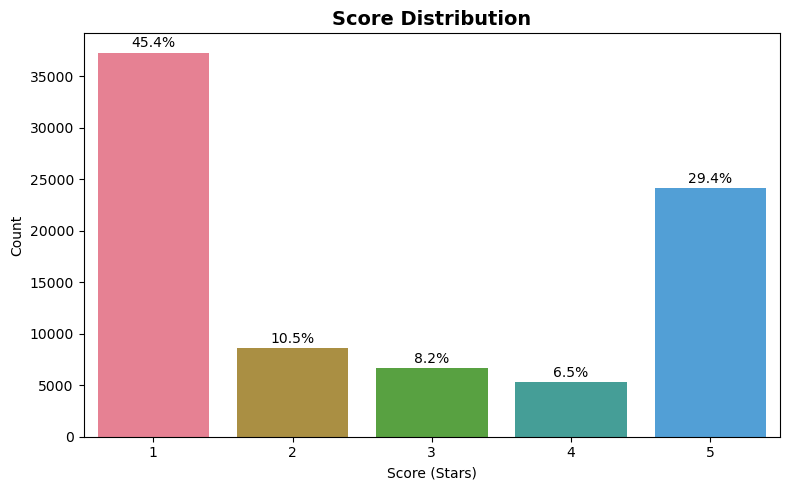

In [19]:
# Score distribution with percentages
fig, ax = plt.subplots(figsize=(8, 5))
score_counts = df["score"].value_counts().sort_index()
bars = sns.barplot(x=score_counts.index, y=score_counts.values, ax=ax)

for bar, count in zip(bars.patches, score_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("Score Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Score (Stars)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

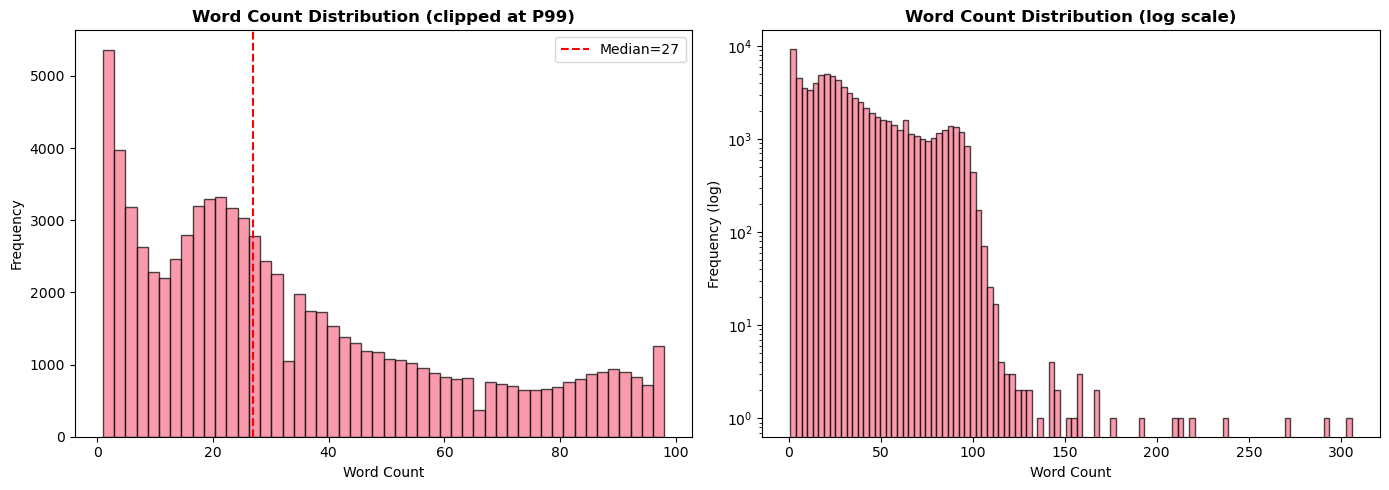

Word count percentiles: P25=13, P50=27, P75=50, P95=90, P99=98


In [21]:
# Word count distribution (two panels: clipped + log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99 = df["word_count"].quantile(0.99)
axes[0].hist(df["word_count"].clip(upper=p99), bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(df["word_count"].median(), color="red", linestyle="--",
                label=f"Median={df['word_count'].median():.0f}")
axes[0].set_title("Word Count Distribution (clipped at P99)", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df["word_count"], bins=100, edgecolor="black", alpha=0.7)
axes[1].set_yscale("log")
axes[1].set_title("Word Count Distribution (log scale)", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency (log)")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}word_count_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Word count percentiles: P25={df['word_count'].quantile(0.25):.0f}, "
      f"P50={df['word_count'].quantile(0.5):.0f}, P75={df['word_count'].quantile(0.75):.0f}, "
      f"P95={df['word_count'].quantile(0.95):.0f}, P99={df['word_count'].quantile(0.99):.0f}")

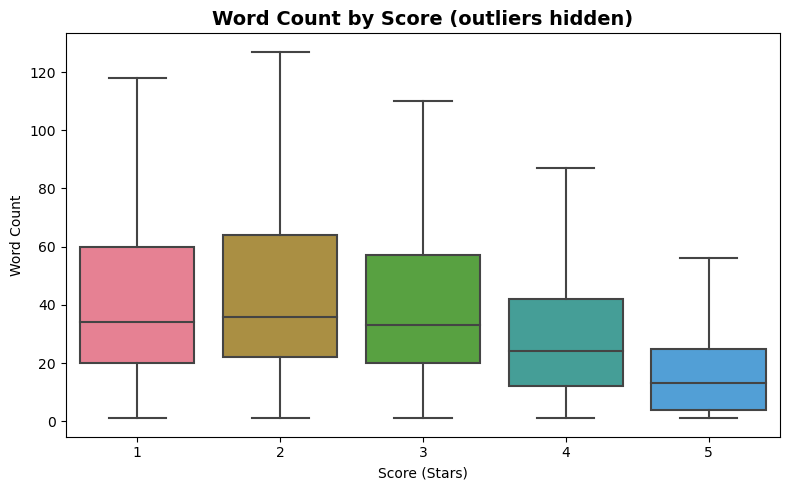

In [22]:
# Word count vs score (boxplot)
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="score", y="word_count", ax=ax, showfliers=False)
ax.set_title("Word Count by Score (outliers hidden)", fontsize=14, fontweight="bold")
ax.set_xlabel("Score (Stars)")
ax.set_ylabel("Word Count")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}word_count_vs_score.png", dpi=300, bbox_inches="tight")
plt.show()

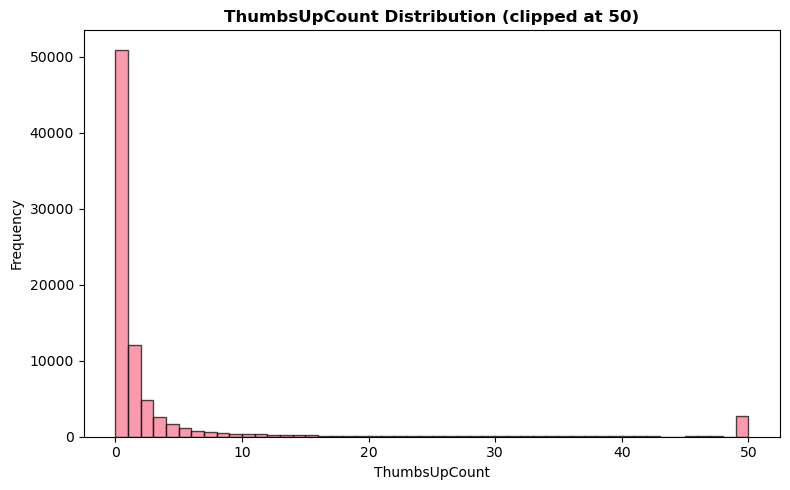

ThumbsUpCount stats:
count    82069.00
mean         8.98
std         69.06
min          0.00
25%          0.00
50%          0.00
75%          1.00
max       5660.00
Name: thumbsUpCount, dtype: float64

Reviews with 0 thumbs up: 50905 (62.0%)


In [23]:
# ThumbsUp distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["thumbsUpCount"].clip(upper=50), bins=50, edgecolor="black", alpha=0.7)
ax.set_title("ThumbsUpCount Distribution (clipped at 50)", fontweight="bold")
ax.set_xlabel("ThumbsUpCount")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}thumbsup_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"ThumbsUpCount stats:")
print(df["thumbsUpCount"].describe().round(2))
print(f"\nReviews with 0 thumbs up: {(df['thumbsUpCount']==0).sum()} ({(df['thumbsUpCount']==0).mean()*100:.1f}%)")

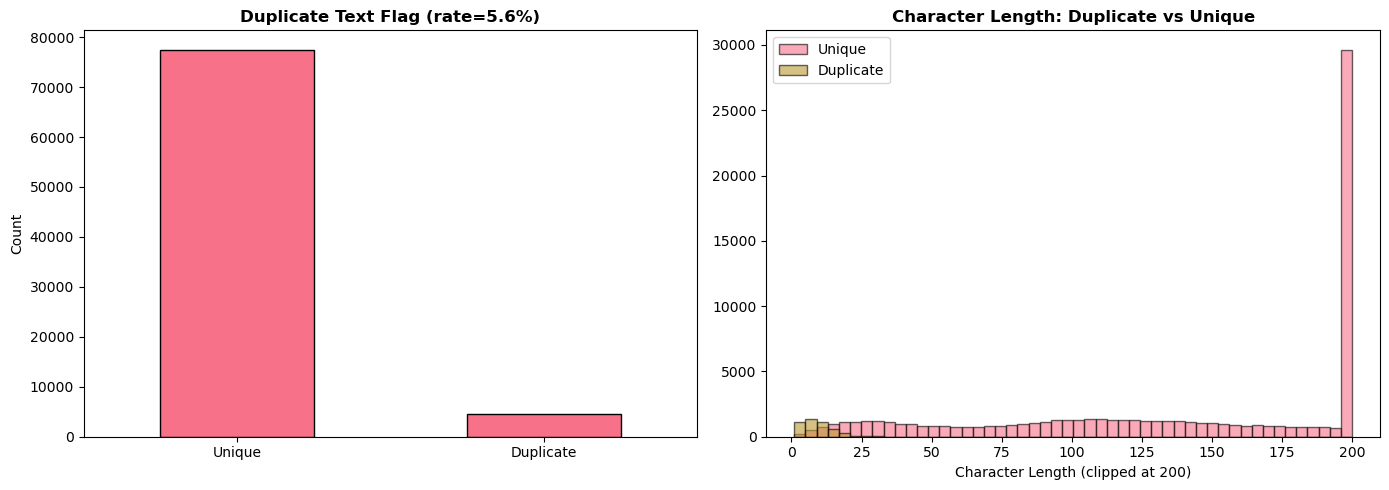


Top 10 most repeated review texts:
good         606
great        333
love it      161
excellent    156
awesome      115
nice         106
very good     99
ok            71
great app     61
amazing       61
Name: content_clean, dtype: int64


In [ ]:
# Duplicate text analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dup_rate = df["is_duplicate_text"].mean() * 100
df["is_duplicate_text"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title(f"Duplicate Text Flag (rate={dup_rate:.1f}%)", fontweight="bold")
axes[0].set_xticklabels(["Unique", "Duplicate"], rotation=0)
axes[0].set_ylabel("Count")

axes[1].hist(df.loc[df["is_duplicate_text"]==0, "char_len"].clip(upper=200), bins=50,
             alpha=0.6, label="Unique", edgecolor="black")
axes[1].hist(df.loc[df["is_duplicate_text"]==1, "char_len"].clip(upper=200), bins=50,
             alpha=0.6, label="Duplicate", edgecolor="black")
axes[1].set_title("Character Length: Duplicate vs Unique", fontweight="bold")
axes[1].set_xlabel("Character Length (clipped at 200)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{IMG_DIR}duplicate_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nTop 10 most repeated review texts:")
print(df.loc[df["is_duplicate_text"]==1, "content_clean"].value_counts().head(10))

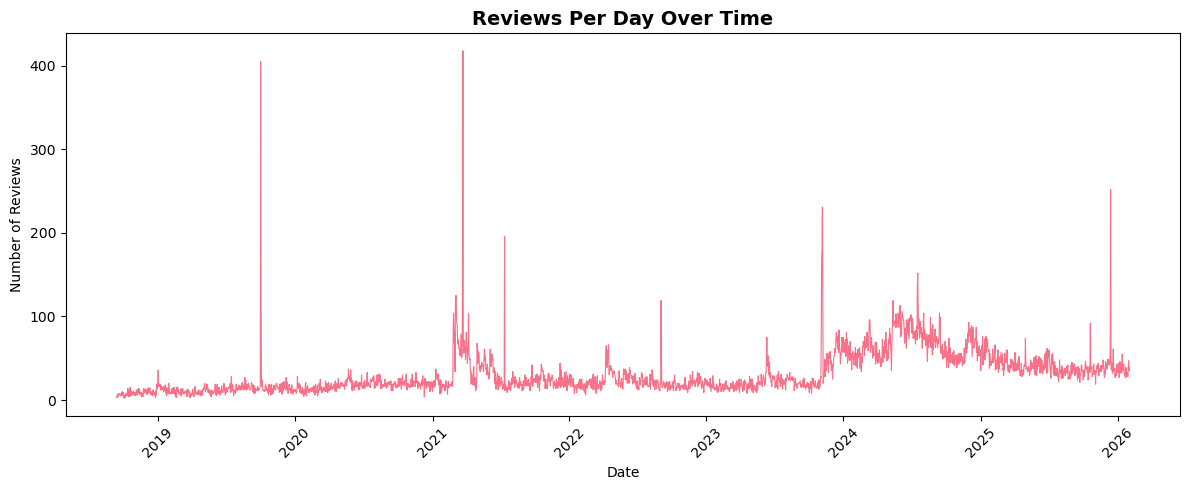

Date range: 2018-09-12 to 2026-02-01
Peak day: 2021-03-23 with 418 reviews


In [58]:
# Reviews over time (daily count)
fig, ax = plt.subplots(figsize=(12, 5))
daily = df.groupby("date").size()
ax.plot(daily.index, daily.values, linewidth=0.8)
ax.set_title("Reviews Per Day Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}reviews_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Date range: {daily.index.min()} to {daily.index.max()}")
print(f"Peak day: {daily.idxmax()} with {daily.max()} reviews")

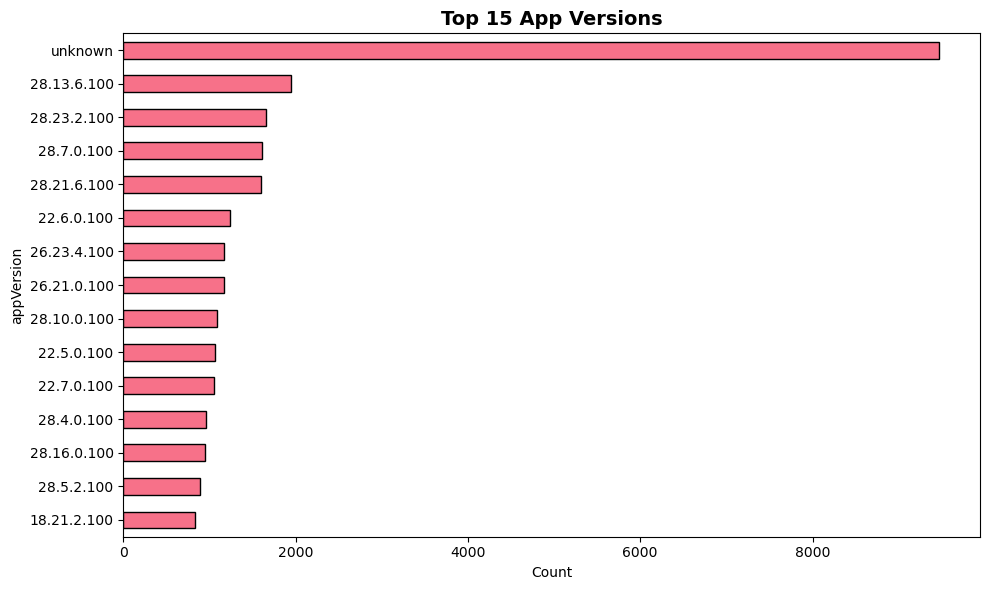

In [25]:
# App version frequency (top 15)
fig, ax = plt.subplots(figsize=(10, 6))
top_ver = df["appVersion"].value_counts().head(15)
top_ver.sort_values().plot(kind="barh", ax=ax, edgecolor="black")
ax.set_title("Top 15 App Versions", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.set_ylabel("appVersion")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}app_version_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

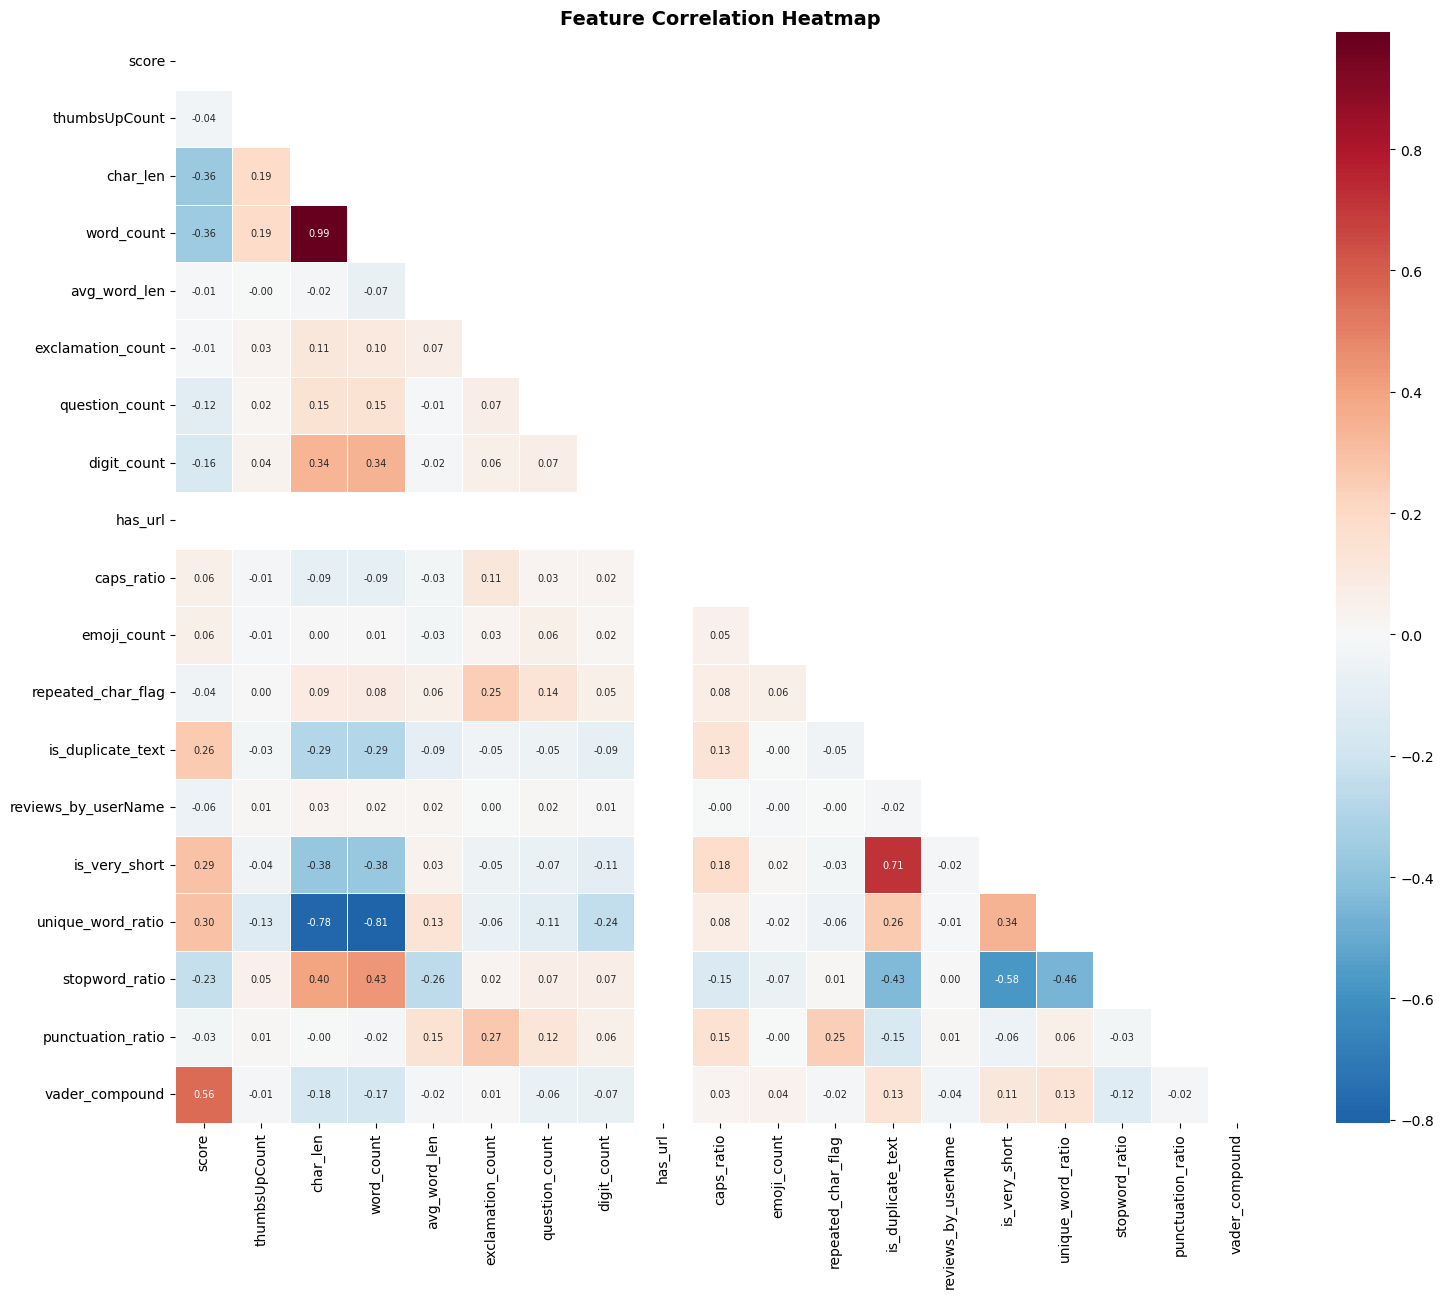

Strong correlations (|r| > 0.5):
  char_len <-> word_count: r=0.992
  word_count <-> unique_word_ratio: r=-0.805
  char_len <-> unique_word_ratio: r=-0.778
  is_duplicate_text <-> is_very_short: r=0.713
  is_very_short <-> stopword_ratio: r=-0.58
  score <-> vader_compound: r=0.564


In [26]:
# Correlation heatmap of numeric features
numeric_features = [
    "score", "thumbsUpCount", "char_len", "word_count", "avg_word_len",
    "exclamation_count", "question_count", "digit_count", "has_url",
    "caps_ratio", "emoji_count", "repeated_char_flag", "is_duplicate_text",
    "reviews_by_userName", "is_very_short", "unique_word_ratio",
    "stopword_ratio", "punctuation_ratio", "vader_compound"
]

corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Print strongest correlations (|r| > 0.5)
strong = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            strong.append((corr_matrix.index[i], corr_matrix.columns[j], round(r, 3)))
if strong:
    print("Strong correlations (|r| > 0.5):")
    for a, b, r in sorted(strong, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {a} <-> {b}: r={r}")

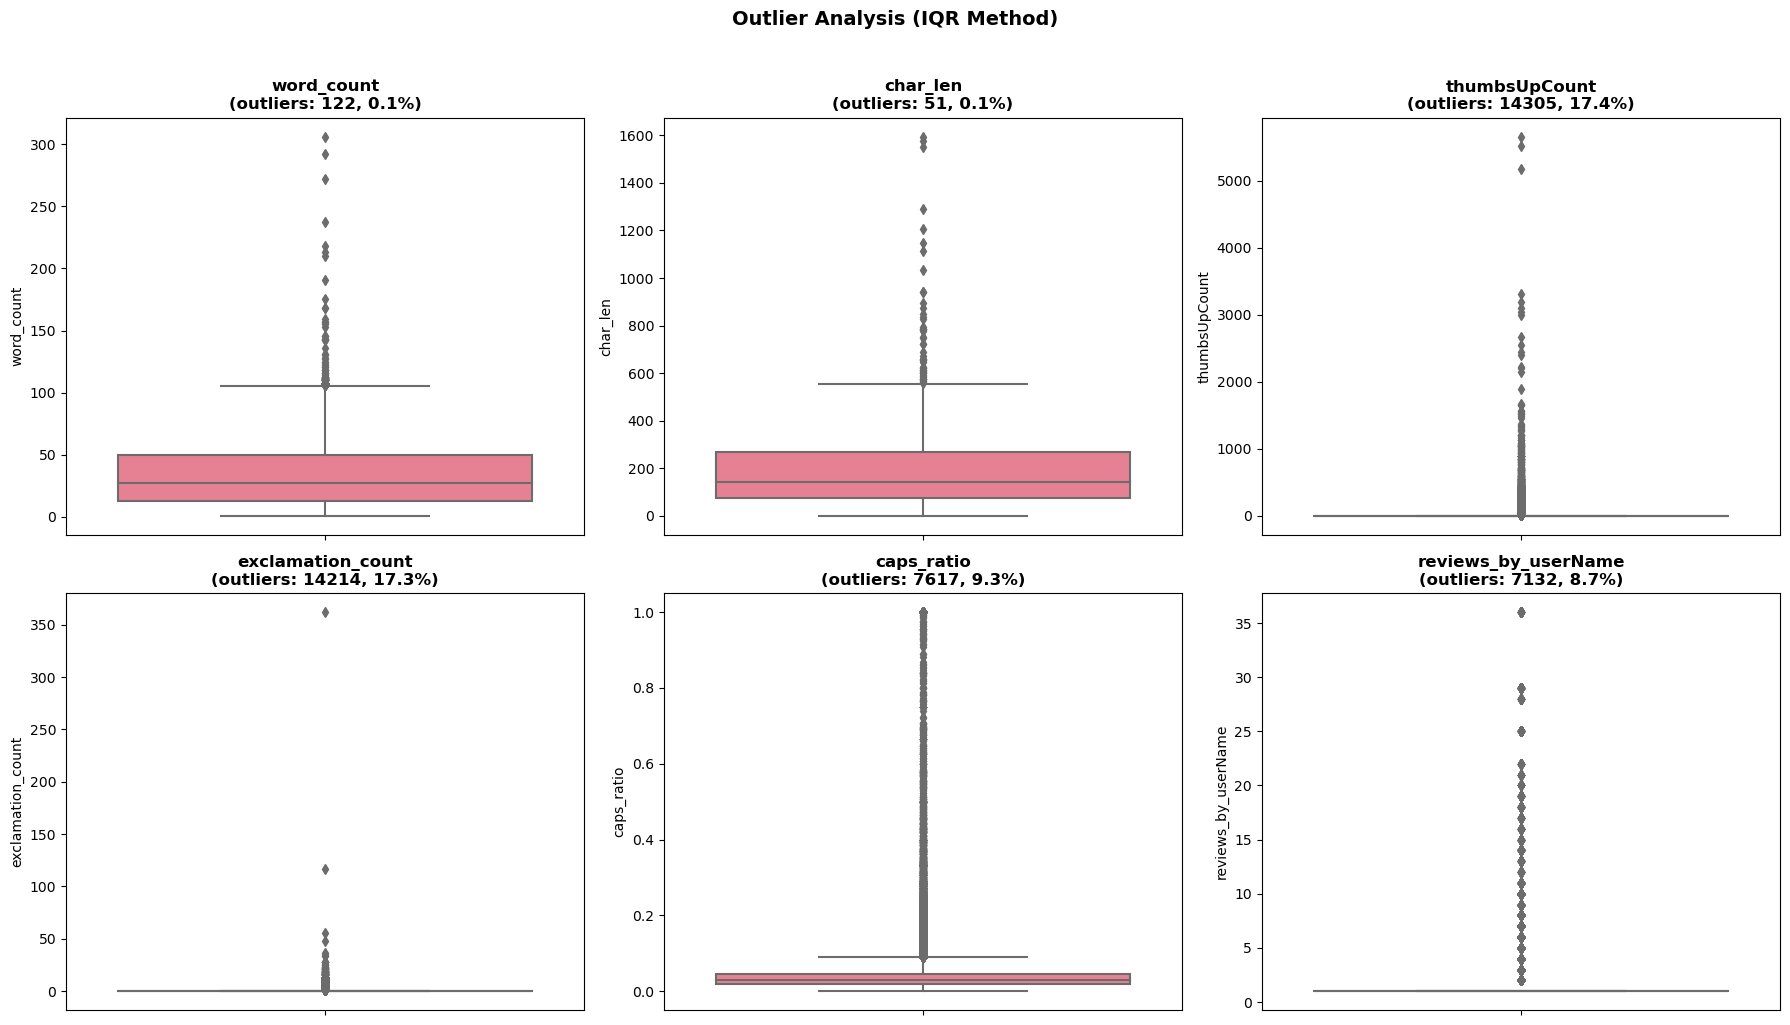

,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
0,word_count,13.00,50.00,37.00,-42.50,105.50,122,0.15
1,char_len,74.00,267.00,193.00,-215.50,556.50,51,0.06
2,thumbsUpCount,0.00,1.00,1.00,-1.50,2.50,14305,17.43
3,exclamation_count,0.00,0.00,0.00,0.00,0.00,14214,17.32
4,caps_ratio,0.02,0.05,0.03,-0.02,0.09,7617,9.28
5,reviews_by_userName,1.00,1.00,0.00,1.00,1.00,7132,8.69


In [27]:
# Outlier analysis on key numeric features (IQR method)
outlier_features = ["word_count", "char_len", "thumbsUpCount",
                    "exclamation_count", "caps_ratio", "reviews_by_userName"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

outlier_summary = []
for idx, feat in enumerate(outlier_features):
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feat] < lower) | (df[feat] > upper)).sum()
    pct = n_outliers / len(df) * 100

    outlier_summary.append({"feature": feat, "Q1": Q1, "Q3": Q3, "IQR": IQR,
                            "lower_bound": lower, "upper_bound": upper,
                            "n_outliers": n_outliers, "pct_outliers": round(pct, 2)})

    sns.boxplot(data=df, y=feat, ax=axes[idx])
    axes[idx].set_title(f"{feat}\n(outliers: {n_outliers}, {pct:.1f}%)", fontweight="bold")

plt.suptitle("Outlier Analysis (IQR Method)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}outlier_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame(outlier_summary).round(2)

In [28]:
# Grouped summary table: mean features by score
group_features = [
    "word_count", "char_len", "caps_ratio", "exclamation_count",
    "question_count", "emoji_count", "unique_word_ratio", "stopword_ratio",
    "vader_compound", "thumbsUpCount", "is_duplicate_text", "is_very_short"
]

grouped = df.groupby("score")[group_features].agg(["mean", "median"]).round(3)
grouped.columns = [f"{feat}_{stat}" for feat, stat in grouped.columns]

print("Feature Summary by Score:")
grouped.T

Feature Summary by Score:


score,1,2,3,4,5
word_count_mean,41.326,43.385,40.135,30.664,18.515
word_count_median,34.000,36.000,33.000,24.000,13.000
char_len_mean,223.388,232.715,213.558,162.917,100.037
char_len_median,186.000,195.000,174.000,130.000,71.000
caps_ratio_mean,0.046,0.040,0.039,0.043,0.058
caps_ratio_median,0.030,0.029,0.028,0.028,0.033
exclamation_count_mean,0.457,0.339,0.283,0.247,0.439
exclamation_count_median,0.000,0.000,0.000,0.000,0.000
question_count_mean,0.173,0.183,0.161,0.079,0.021
question_count_median,0.000,0.000,0.000,0.000,0.000


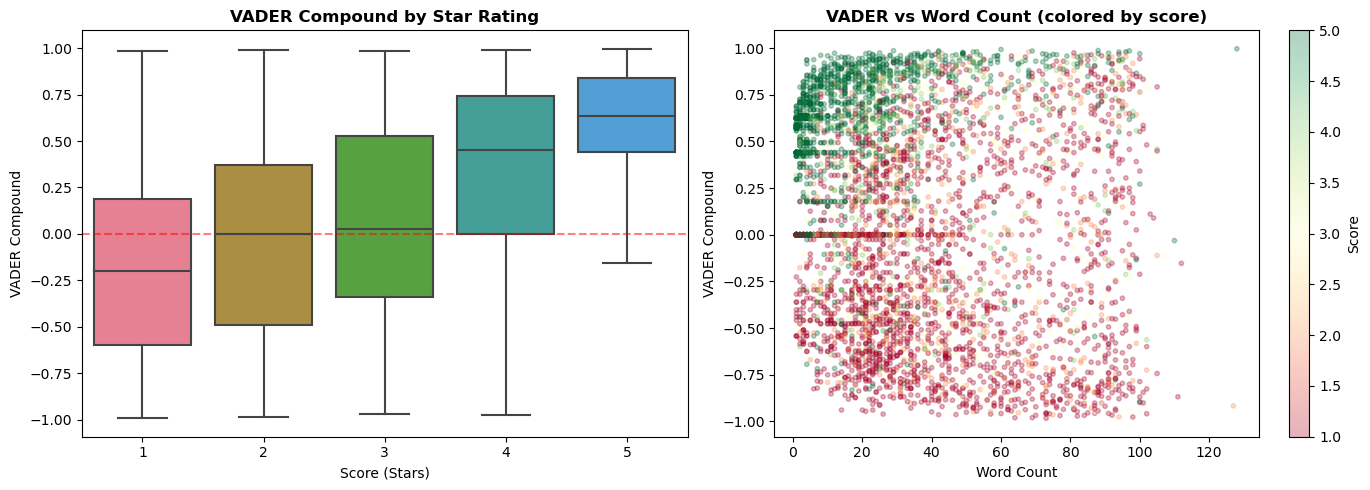

In [29]:
# VADER vs Score alignment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="score", y="vader_compound", ax=axes[0], showfliers=False)
axes[0].set_title("VADER Compound by Star Rating", fontweight="bold")
axes[0].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Score (Stars)")
axes[0].set_ylabel("VADER Compound")

sample = df.sample(min(5000, len(df)), random_state=RANDOM_SEED)
scatter = axes[1].scatter(sample["word_count"], sample["vader_compound"],
                          c=sample["score"], cmap="RdYlGn", alpha=0.3, s=10)
axes[1].set_title("VADER vs Word Count (colored by score)", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("VADER Compound")
plt.colorbar(scatter, ax=axes[1], label="Score")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}vader_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

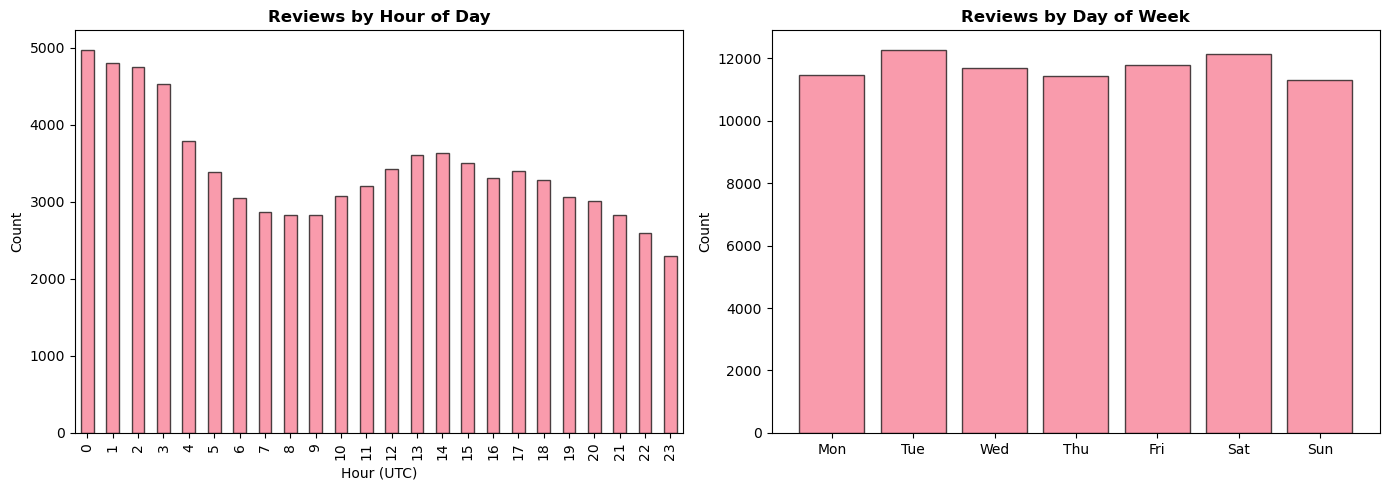

In [30]:
# Temporal patterns: hour and day of week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0],
                                             edgecolor="black", alpha=0.7)
axes[0].set_title("Reviews by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Count")

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_counts = df["day_of_week"].value_counts().sort_index()
axes[1].bar(dow_labels, dow_counts.values, edgecolor="black", alpha=0.7)
axes[1].set_title("Reviews by Day of Week", fontweight="bold")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}temporal_patterns.png", dpi=300, bbox_inches="tight")
plt.show()

### Skewed Feature Documentation

Several features exhibit strong right-skew (`word_count`, `char_len`, `thumbsUpCount`, `exclamation_count`, `reviews_by_userName`). Log-transformation can help if used in models that assume normality (e.g., regression). For tree-based models and TF-IDF-based NLP pipelines, raw values work fine.

The anomaly detection notebook (Phase 2) applies `StandardScaler` before Isolation Forest / SVM / LOF, which handles scale but not skew. Consider log-transforms for distance-based methods (SVM, LOF) during Phase 2.

## 6. Sentiment Labeling & Class Imbalance Analysis

In [31]:
# Binary sentiment: 0 = Negative (1-2 stars), 1 = Positive (4-5 stars)
# 3-star "neutral" reviews are excluded for sentiment analysis

df_with_neutrals = df.copy()   # Keep copy WITH neutrals for anomaly detection output

# Create sentiment labels (NaN for neutrals)
df["sentiment"] = np.where(
    df["score"].isin([4, 5]), 1,
    np.where(df["score"].isin([1, 2]), 0, np.nan)
)

neutral_count = df["sentiment"].isna().sum()
df_sentiment = df.dropna(subset=["sentiment"]).copy()
df_sentiment["sentiment"] = df_sentiment["sentiment"].astype(int)

print(f"Total reviews: {len(df)}")
print(f"Neutral (3-star) reviews excluded: {neutral_count} ({neutral_count/len(df)*100:.1f}%)")
print(f"Reviews for sentiment analysis: {len(df_sentiment)}")
print(f"\nSentiment distribution:")
print(df_sentiment["sentiment"].value_counts())

Total reviews: 82069
Neutral (3-star) reviews excluded: 6709 (8.2%)
Reviews for sentiment analysis: 75360

Sentiment distribution:
0    45927
1    29433
Name: sentiment, dtype: int64


Class Imbalance Analysis:
  Negative (0): 45927 (60.9%)
  Positive (1): 29433 (39.1%)
  Imbalance ratio (neg/pos): 1.56

The dataset has moderate class imbalance (~61% negative, ~39% positive).
Recommendations for downstream modeling:
  1. Use F1-score (not accuracy) as the primary evaluation metric
  2. Use stratified train/test splits and stratified K-fold CV
  3. Consider class_weight='balanced' in models that support it
  4. Monitor per-class precision and recall separately


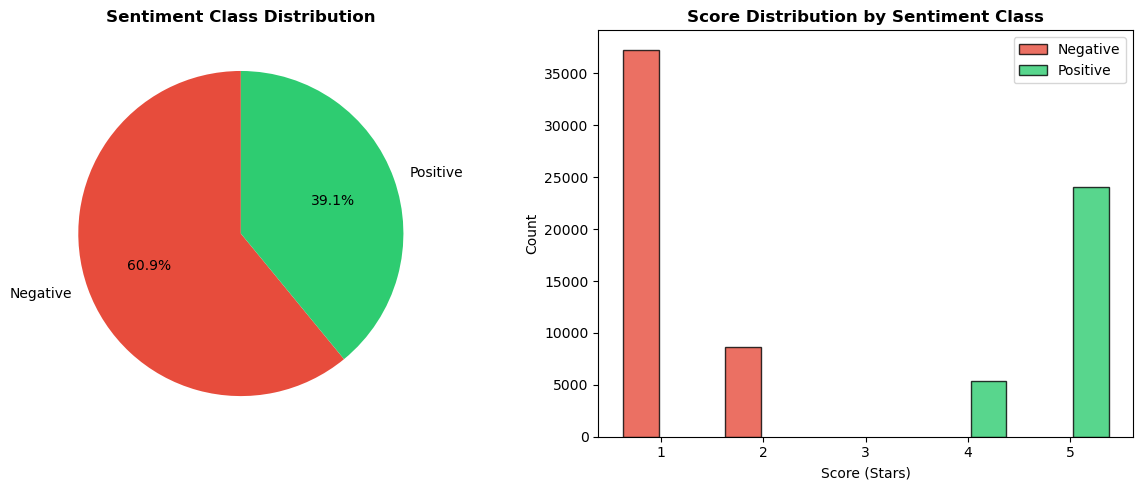

In [32]:
# Class imbalance analysis
neg_count = (df_sentiment["sentiment"] == 0).sum()
pos_count = (df_sentiment["sentiment"] == 1).sum()
imbalance_ratio = neg_count / pos_count

print(f"Class Imbalance Analysis:")
print(f"  Negative (0): {neg_count} ({neg_count/len(df_sentiment)*100:.1f}%)")
print(f"  Positive (1): {pos_count} ({pos_count/len(df_sentiment)*100:.1f}%)")
print(f"  Imbalance ratio (neg/pos): {imbalance_ratio:.2f}")
print()
print("The dataset has moderate class imbalance (~61% negative, ~39% positive).")
print("Recommendations for downstream modeling:")
print("  1. Use F1-score (not accuracy) as the primary evaluation metric")
print("  2. Use stratified train/test splits and stratified K-fold CV")
print("  3. Consider class_weight='balanced' in models that support it")
print("  4. Monitor per-class precision and recall separately")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie([neg_count, pos_count], labels=["Negative", "Positive"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"], startangle=90)
axes[0].set_title("Sentiment Class Distribution", fontweight="bold")

for sent_val, label, color in [(0, "Negative", "#e74c3c"), (1, "Positive", "#2ecc71")]:
    subset = df_sentiment[df_sentiment["sentiment"] == sent_val]
    score_dist = subset["score"].value_counts().sort_index()
    offset = 0.2 if sent_val == 1 else -0.2
    axes[1].bar(score_dist.index + offset, score_dist.values,
                width=0.35, label=label, color=color, alpha=0.8, edgecolor="black")

axes[1].set_title("Score Distribution by Sentiment Class", fontweight="bold")
axes[1].set_xlabel("Score (Stars)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{IMG_DIR}class_imbalance_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Save Outputs & Final Schema

Two output files:
1. **`reviews_clean_all.csv`** — All reviews including neutrals, for anomaly detection (Phase 2)
2. **`reviews_clean_full.csv`** — Neutrals removed, sentiment labeled, for sentiment analysis (Phase 3)



In [33]:
# Output 1: ALL reviews including 3-star neutrals (for anomaly detection)
out_all = df_with_neutrals.copy()

# Drop intermediate columns not needed downstream
cols_to_drop = ["date"]
out_all = out_all.drop(columns=[c for c in cols_to_drop if c in out_all.columns])

out_all.to_csv(f"{IMG_DIR}reviews_clean_all.csv", index=False)
print(f"Saved: reviews_clean_all.csv")
print(f"  Shape: {out_all.shape}")

Saved: reviews_clean_all.csv
  Shape: (82069, 32)


In [34]:
# Output 2: Neutrals removed + sentiment column (for sentiment analysis)
out_sentiment = df_sentiment.copy()

cols_to_drop = ["date"]
out_sentiment = out_sentiment.drop(columns=[c for c in cols_to_drop if c in out_sentiment.columns])

out_sentiment.to_csv(f"{IMG_DIR}reviews_clean_full.csv", index=False)
print(f"Saved: reviews_clean_full.csv")
print(f"  Shape: {out_sentiment.shape}")

Saved: reviews_clean_full.csv
  Shape: (75360, 33)


In [35]:
# Final column schema
print("=" * 70)
print("FINAL COLUMN SCHEMA - reviews_clean_full.csv (sentiment-ready)")
print("=" * 70)
schema = pd.DataFrame({
    "column": out_sentiment.columns,
    "dtype": out_sentiment.dtypes.values,
    "non_null": out_sentiment.notna().sum().values,
    "null": out_sentiment.isna().sum().values,
})
print(schema.to_string(index=False))
print(f"\nTotal rows: {len(out_sentiment)}")
print(f"Total columns: {len(out_sentiment.columns)}")

print("\n" + "=" * 70)
print("FINAL COLUMN SCHEMA - reviews_clean_all.csv (for anomaly detection)")
print("=" * 70)
schema_all = pd.DataFrame({
    "column": out_all.columns,
    "dtype": out_all.dtypes.values,
    "non_null": out_all.notna().sum().values,
    "null": out_all.isna().sum().values,
})
print(schema_all.to_string(index=False))
print(f"\nTotal rows: {len(out_all)}")
print(f"Total columns: {len(out_all.columns)}")

FINAL COLUMN SCHEMA - reviews_clean_full.csv (sentiment-ready)
             column          dtype  non_null  null
           reviewId         object     75360     0
           userName         object     75360     0
            content         object     75360     0
              score          int64     75360     0
      thumbsUpCount          int32     75360     0
                 at datetime64[ns]     75360     0
         appVersion         object     75360     0
               year          int64     75360     0
              month          int64     75360     0
        day_of_week          int64     75360     0
               hour          int64     75360     0
      content_clean         object     75360     0
  is_anonymous_user          int32     75360     0
           char_len          int64     75360     0
         word_count          int64     75360     0
       avg_word_len        float64     75360     0
  exclamation_count          int64     75360     0
     question_count